In [ ]:
import os
import math
import pickle
import dataclasses
import inspect
import warnings
from typing import Any, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.func import vmap, grad, functional_call
from torch.utils._pytree import tree_map

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import pennylane as qml
from opacus import PrivacyEngine

np.set_printoptions(threshold=np.inf, suppress=True)
torch.set_printoptions(threshold=np.inf, sci_mode=True)
warnings.filterwarnings("ignore", message="Full backward hook is firing")

In [ ]:
@dataclasses.dataclass
class Config:
    seed: int = 123
    n_samples: int = 2048
    n_features: int = 16
    n_classes: int = 4
    test_size: float = 0.2
    val_size: float = 0.3

    epochs: int = 100
    batch_size: int = 64
    n_exp: int = 10

    activation: dict = dataclasses.field(default_factory=lambda: {"type": "tanh", "layers": "all"})

    quantum_encoding: str = "amplitude"
    n_layers_pure: str = "auto"
    shots: Optional[int] = None
    noisy: bool = False

    l2_clip: float = 1.5
    noise_multiplier: float = 0.0
    delta: float = 1e-5

    lrs: dict = dataclasses.field(default_factory=lambda: {
        "classical_no_privacy": 0.08,
        "classical_tf_privacy": 0.05,
        "quantum_no_privacy":   0.02,
        "quantum_tf_privacy":   0.015,
    })

    labels: list = dataclasses.field(default_factory=lambda: [
        "classical_no_privacy",
        "classical_tf_privacy",
        "quantum_no_privacy",
        "quantum_tf_privacy",
    ])

    save_path: str = "./experiment_summaries/summaries_final.pkl"

    @property
    def measure_qubits(self):
        return list(range(self.n_classes))


cfg = Config()

In [ ]:
def set_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)


def build_dataset(cfg: Config):
    X, y = make_classification(
        n_classes=cfg.n_classes,
        n_samples=cfg.n_samples,
        n_features=cfg.n_features,
        n_informative=cfg.n_features,
        n_redundant=0,
        n_repeated=0,
        n_clusters_per_class=1,
        class_sep=0.8,
        flip_y=0.1,
        shift=1.0,
        scale=5.0,
        random_state=cfg.seed,
    )
    X = StandardScaler().fit_transform(X)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=cfg.test_size, random_state=cfg.seed, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=cfg.val_size, random_state=cfg.seed, stratify=y_temp)
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


def make_data_loader(X, y, batch_size, shuffle):
    dataset = torch.utils.data.TensorDataset(X, y)
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def save_summaries(summaries, cfg: Config):
    config_dict = {m[0]: m[1] for m in inspect.getmembers(cfg)
                   if not m[0].startswith("_") and not inspect.ismethod(m[1])}
    os.makedirs(os.path.dirname(cfg.save_path), exist_ok=True)
    with open(cfg.save_path, "wb") as f:
        pickle.dump({"summaries": summaries, "config": config_dict}, f,
                    protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
class TauCrossEntropyLoss(nn.Module):
    def __init__(self, tau: float = 1.0, reduction: str = "mean"):
        super().__init__()
        self.tau = nn.Parameter(torch.tensor(tau, dtype=torch.float32), requires_grad=False)
        self.reduction = reduction

    def forward(self, logits, targets):
        return F.cross_entropy(self.tau * logits, targets, reduction=self.reduction) / self.tau


class ClassicalNet(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.fc1 = nn.Linear(cfg.n_features, 4)
        self.fc2 = nn.Linear(4, 4)
        self.fc3 = nn.Linear(4, 4)
        self.fc4 = nn.Linear(4, cfg.n_classes)

        act_type = cfg.activation["type"]
        Act = {
            "tanh": nn.Tanh, "relu": nn.ReLU, "lrelu": nn.LeakyReLU,
            "prelu": nn.PReLU, "sigmoid": nn.Sigmoid,
        }.get(act_type, nn.ReLU)
        self.act1, self.act2, self.act3 = Act(), Act(), Act()
        self.act_layers = cfg.activation["layers"]

    def forward(self, x):
        h = self.fc1(x)
        if self.act_layers in ("first", "all"):
            h = self.act1(h)
        h = self.fc2(h)
        if self.act_layers == "all":
            h = self.act2(h)
        h = self.fc3(h)
        if self.act_layers == "all":
            h = self.act3(h)
        return self.fc4(h)


def make_vqc(encoding, n_qubits, n_layers, measure_qubits, shots, noisy):
    has_shot_noise = shots is not None
    diff_method = "parameter-shift" if has_shot_noise else "backprop"
    if noisy:
        device_name = "default.mixed"
    else:
        device_name = "lightning.qubit" if has_shot_noise else "default.qubit"
    device = qml.device(device_name, wires=n_qubits, shots=shots)

    @qml.qnode(device, interface="torch", diff_method=diff_method)
    def circuit(inputs, weights):
        if encoding == "amplitude":
            amps = F.normalize(inputs)
            qml.AmplitudeEmbedding(amps, wires=range(n_qubits), normalize=True, pad_with=0)
        else:
            qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="X")
        for l in range(n_layers):
            for i in range(n_qubits):
                qml.RZ(weights[(i * n_layers + l) * 3],     wires=i)
                qml.RY(weights[(i * n_layers + l) * 3 + 1], wires=i)
                qml.RZ(weights[(i * n_layers + l) * 3 + 2], wires=i)
            for i in range(n_qubits):
                qml.CNOT(wires=[i, (i + 1) % n_qubits])
        return [qml.expval(qml.PauliZ(i)) for i in measure_qubits]

    return circuit


def functional_qnode(inputs, params, *, encoding, n_qubits, n_layers, measure_qubits,
                     shots=None, noisy=False):
    key = "_module.qlayer.weights" if "_module.qlayer.weights" in params else "qlayer.weights"
    return make_vqc(encoding, n_qubits, n_layers, measure_qubits, shots, noisy)(
        inputs, params[key])


class QuantumNet(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        if cfg.quantum_encoding == "angle":
            n_qubits = cfg.n_features
        else:
            n_qubits = int(np.ceil(np.log2(cfg.n_features)))

        if cfg.n_layers_pure == "auto":
            c_model = ClassicalNet(cfg)
            n_clas = sum(p.numel() for p in c_model.parameters() if p.requires_grad)
            n_layers = int(math.ceil(n_clas / (3 * n_qubits)))
        else:
            n_layers = int(cfg.n_layers_pure)

        self.encoding = cfg.quantum_encoding
        self.measure_qubits = cfg.measure_qubits
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.shots = cfg.shots
        self.noisy = cfg.noisy

        self.qlayer = qml.qnn.TorchLayer(
            make_vqc(cfg.quantum_encoding, n_qubits, n_layers, cfg.measure_qubits,
                     cfg.shots, cfg.noisy),
            weight_shapes={"weights": n_layers * n_qubits * 3},
        )

    def forward(self, x):
        return self.qlayer(x)

In [ ]:
def compute_loss(params, sample, target, model, criterion, quantum, private=False):
    batch = sample.unsqueeze(0)
    if quantum:
        predictions = functional_qnode(
            batch, params,
            encoding=model._module.encoding,
            measure_qubits=model._module.measure_qubits,
            n_qubits=model._module.n_qubits,
            n_layers=model._module.n_layers,
            shots=model._module.shots,
            noisy=model._module.noisy,
        )
        if len(predictions[0].shape) == 0:
            predictions = torch.stack(predictions, dim=0)
        else:
            predictions = torch.cat(predictions)
    else:
        predictions = functional_call(model, params, batch).flatten()
    return criterion(predictions, target)


def ft_compute_grad(params, data, target, *args):
    return grad(compute_loss)(params, data, target, *args)


def autograd_compute_grad(params, data, target, model, criterion, quantum, private=False):
    loss = compute_loss(params, data, target, model, criterion, quantum, private)
    if loss.ndim != 0:
        loss = loss.mean()
    keys = list(params.keys())
    leaves = [params[k] for k in keys]
    grads = torch.autograd.grad(loss, leaves, retain_graph=False, create_graph=False)
    return {k: g for k, g in zip(keys, grads)}


def autograd_compute_per_sample_grads(params, X, y, model, criterion, quantum, private=False):
    grads_list = [autograd_compute_grad(params, X[i], y[i], model, criterion, quantum, private)
                  for i in range(X.shape[0])]
    return tree_map(lambda *xs: torch.stack(xs, dim=0), *grads_list)


def flatten_per_sample(per_sample_grads, keys):
    chunks = [per_sample_grads[k].reshape(per_sample_grads[k].shape[0], -1).detach()
              for k in keys]
    return torch.cat(chunks, dim=1)

In [ ]:
def _polyak_update(ema_params, named_params, decay):
    with torch.no_grad():
        for k, v in named_params:
            ema_params[k].mul_(decay).add_(v.detach(), alpha=1.0 - decay)


def _swap_params(target_module, source_state):
    saved = {}
    with torch.no_grad():
        for k, v in target_module.named_parameters():
            saved[k] = v.detach().clone()
            v.copy_(source_state[k])
    return saved


def _restore_params(target_module, saved):
    with torch.no_grad():
        for k, v in target_module.named_parameters():
            v.copy_(saved[k])


def train(model, opt, train_loader, val_loader, criterion, *,
          cfg: Config, quantum=False, private=False,
          privacy_config=None, scheduler=None, ema_decay=0.99):
    privacy_config = privacy_config or {}
    if private:
        pe = PrivacyEngine()
        if "target_epsilon" in privacy_config:
            model, opt, train_loader = pe.make_private_with_epsilon(
                module=model, optimizer=opt, data_loader=train_loader,
                epochs=cfg.epochs, **privacy_config)
        else:
            model, opt, train_loader = pe.make_private(
                module=model, optimizer=opt, data_loader=train_loader,
                epochs=cfg.epochs, **privacy_config)
    params = dict(model.named_parameters())
    inner = model._module if hasattr(model, "_module") else model

    ema_params = {k: v.detach().clone() for k, v in inner.named_parameters()}

    frozen_X = train_loader.dataset.tensors[0]
    frozen_y = train_loader.dataset.tensors[1]

    ft_compute_per_sample_grads = vmap(
        ft_compute_grad, in_dims=(None, 0, 0, None, None, None, None))

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    grad_dist, frozen_grad_norms = [], []

    def frozen_per_sample_grads():
        use_vmap = quantum and cfg.shots is None
        had_hooks = hasattr(model, "disable_hooks")
        if had_hooks:
            model.disable_hooks()
        try:
            if use_vmap:
                psg = ft_compute_per_sample_grads(
                    params, frozen_X, frozen_y, model, criterion, quantum, private)
            else:
                psg = autograd_compute_per_sample_grads(
                    params, frozen_X, frozen_y, model, criterion, quantum, private)
        finally:
            if had_hooks:
                model.enable_hooks()
        return flatten_per_sample(psg, list(params.keys()))

    for epoch in range(cfg.epochs):
        model.eval()
        v_loss, v_acc = 0.0, 0.0
        for data, target in val_loader:
            output = model(data)
            v_loss += criterion(output, target).item()
            v_acc += (output.argmax(1) == target).float().mean().item()
        val_losses.append(v_loss / len(val_loader))
        val_accs.append(v_acc / len(val_loader))

        model.train()
        t_loss, t_acc = 0.0, 0.0
        for data, target in train_loader:
            opt.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            if private and privacy_config.get("grad_sample_mode") == "no_op":
                if cfg.shots is None:
                    per_sample_grads = ft_compute_per_sample_grads(
                        params, data, target, model, criterion, quantum, private)
                else:
                    per_sample_grads = autograd_compute_per_sample_grads(
                        params, data, target, model, criterion, quantum, private)
                for key, value in per_sample_grads.items():
                    params[key].grad_sample = value.detach()
            else:
                loss.backward()
            t_loss += loss.item()
            t_acc += (output.argmax(1) == target).float().mean().item()
            opt.step()
            _polyak_update(ema_params, list(inner.named_parameters()), ema_decay)
        train_losses.append(t_loss / len(train_loader))
        train_accs.append(t_acc / len(train_loader))

        if private:
            saved = _swap_params(inner, ema_params)
            try:
                G = frozen_per_sample_grads()
            finally:
                _restore_params(inner, saved)
            grad_dist.append(G)
            frozen_grad_norms.append(float(G.mean(0).norm().item()))

        print(f"epoch {epoch:3d} | train loss={train_losses[-1]:.4f} acc={train_accs[-1]:.3f}"
              f" | val loss={val_losses[-1]:.4f} acc={val_accs[-1]:.3f}"
              + (f" | ||grad L(theta_ema)||={frozen_grad_norms[-1]:.4e}" if private else ""))

        if scheduler is not None:
            scheduler.step()

    return {
        "train": {"loss": train_losses, "accuracy": train_accs},
        "val":   {"loss": val_losses,   "accuracy": val_accs},
        "grad_dist": grad_dist,
        "frozen_grad_norms": frozen_grad_norms,
    }

In [ ]:
import math
from opacus.accountants.utils import get_noise_multiplier

base_batch_size  = 64
C_ref            = cfg.l2_clip
C_unclip         = {"classical": 6.0, "quantum": 2.0}
stability_factor = {"classical": 0.5, "quantum": 1.0}
NOISE_K          = 0.0015


def _model_type_of(label):
    return "quantum" if "quantum" in label else "classical"


def lr_for_clip(C, model_type):
    lr_unclip = cfg.lrs[f"{model_type}_no_privacy"]
    lr_clip   = cfg.lrs[f"{model_type}_tf_privacy"]
    C_unc     = C_unclip[model_type]
    sf        = stability_factor[model_type]
    if C >= C_unc:
        return lr_unclip
    lr_clip_eff = lr_clip * sf
    if C >= C_ref:
        log_clip   = math.log(lr_clip_eff)
        log_unclip = math.log(lr_unclip)
        frac       = (C - C_ref) / (C_unc - C_ref)
        return math.exp(log_clip + (log_unclip - log_clip) * frac)
    return lr_clip_eff * (C_ref / C)


def lr_with_cap(C, sigma, bs, model_type):
    lr_base = lr_for_clip(C, model_type) * (bs / base_batch_size)
    if sigma is None or sigma <= 0:
        return lr_base
    cap = NOISE_K * bs / (sigma * C)
    return min(lr_base, cap)


def auto_lr(label, cfg, sigma=0.0):
    mt = _model_type_of(label)
    C  = 1e6 if "no_privacy" in label else cfg.l2_clip
    return lr_with_cap(C, sigma, cfg.batch_size, mt)

In [ ]:
def run_all(cfg: Config):
    set_seed(cfg.seed)
    criterion = TauCrossEntropyLoss(tau=1.0)

    summaries = {}
    data = build_dataset(cfg)

    for label in cfg.labels:
        print(f"\n=== {label} ===")
        quantum = "quantum" in label
        private = True
        summaries.setdefault(label, [])
        lr = auto_lr(label, cfg, sigma=0.0)
        print(f"  → {label}: lr={lr:.5f}  (manual anchor: {cfg.lrs[label]})")

        loaders = []
        for i, split in enumerate(data):
            loaders.append(make_data_loader(
                X=torch.from_numpy(split[0].astype(np.float32)),
                y=torch.from_numpy(split[1]),
                batch_size=cfg.batch_size,
                shuffle=(i == 0),
            ))
        train_loader, val_loader, test_loader = loaders

        for i in range(cfg.n_exp):
            print(f"experiment {i}")
            if quantum:
                model = QuantumNet(cfg)
            else:
                model = ClassicalNet(cfg)
            opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
            scheduler = None

            result = train(
                model, opt, train_loader, val_loader, criterion,
                cfg=cfg,
                quantum=quantum,
                private=private,
                scheduler=scheduler,
                privacy_config={
                    "clipping": "flat",
                    "grad_sample_mode": "no_op" if quantum else "hooks",
                    "max_grad_norm": 1000.0 if "no_privacy" in label else cfg.l2_clip,
                    "noise_multiplier": cfg.noise_multiplier,
                    "target_delta": cfg.delta,
                },
            )
            summaries[label].append(result)

    return summaries

In [ ]:
s = run_all(cfg)
save_summaries(s, cfg)

In [ ]:
def _clip_by_l2_norm(G: np.ndarray, clip_norm: float):
    norms = np.linalg.norm(G, axis=1)
    safe = np.maximum(norms, 1e-12)
    scales = np.minimum(1.0, clip_norm / safe)
    return G * scales[:, None], norms, scales


def _trace_cov(X: np.ndarray) -> float:
    Xc = X - X.mean(axis=0, keepdims=True)
    return float(np.mean(np.sum(Xc * Xc, axis=1)))


def _directional_variance(X: np.ndarray, u: np.ndarray) -> float:
    return float(np.var(X @ u, ddof=0))


def _safe_cos(a, b, eps=1e-12):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < eps or nb < eps:
        return np.nan
    return float(np.dot(a, b) / (na * nb))


def compute_epoch_gradient_metrics(
    G: np.ndarray,
    clip_norm: float = 1.0,
    batch_size: Optional[int] = None,
    noise_multiplier: float = 0.0,
    return_vectors: bool = False,
) -> Dict[str, Any]:
    G = np.asarray(G, dtype=np.float64)
    if G.ndim != 2:
        raise ValueError(f"G must have shape (n_examples, n_params), got {G.shape}")
    n_examples, n_params = G.shape
    B = n_examples if batch_size is None else int(batch_size)
    if B <= 0 or clip_norm <= 0:
        raise ValueError("batch_size and clip_norm must be positive")

    G_clip, norms, scales = _clip_by_l2_norm(G, clip_norm)
    g_mean      = G.mean(axis=0)
    g_clip_mean = G_clip.mean(axis=0)
    bias        = g_clip_mean - g_mean
    g_norm      = float(np.linalg.norm(g_mean))
    g_clip_norm = float(np.linalg.norm(g_clip_mean))
    bias_norm   = float(np.linalg.norm(bias))

    if g_norm > 1e-12:
        u = g_mean / g_norm
        directional_bias_signed    = float(np.dot(u, bias))
        directional_bias_magnitude = -directional_bias_signed
        bias_orth                  = bias - directional_bias_signed * u
        orthogonal_bias_norm       = float(np.linalg.norm(bias_orth))
        rel_bias_norm              = bias_norm / g_norm
        rel_directional_bias       = directional_bias_magnitude / g_norm
        proj_clipped_mean          = float(np.dot(u, g_clip_mean))
    else:
        u = np.zeros_like(g_mean)
        directional_bias_signed = directional_bias_magnitude = np.nan
        orthogonal_bias_norm = rel_bias_norm = rel_directional_bias = np.nan
        proj_clipped_mean = np.nan

    cosine_alignment = _safe_cos(g_mean, g_clip_mean)

    clipped_mask     = norms > clip_norm
    p_clip           = float(np.mean(clipped_mask))
    excess           = np.maximum(norms - clip_norm, 0.0)
    mean_excess_norm = float(np.mean(excess))
    mean_sq_excess   = float(np.mean(excess ** 2))

    trace_cov_unclipped = _trace_cov(G)
    trace_cov_clipped   = _trace_cov(G_clip)
    var_mean_unclipped  = trace_cov_unclipped / B
    var_mean_clipped    = trace_cov_clipped   / B
    noise_trace         = (noise_multiplier * clip_norm / B) ** 2 * n_params
    noise_dir_var       = (noise_multiplier * clip_norm / B) ** 2

    mse_bias_sq       = bias_norm ** 2
    mse_sampling_var  = var_mean_clipped
    mse_noise_var     = noise_trace
    mse_total         = mse_bias_sq + mse_sampling_var + mse_noise_var
    mse_clipping_only = mse_bias_sq + mse_sampling_var

    if g_norm > 1e-12:
        dir_sampling_var = _directional_variance(G_clip, u) / B
        dir_total_var    = dir_sampling_var + noise_dir_var
        dir_bias_sq      = directional_bias_signed ** 2
        snr_dir  = (proj_clipped_mean ** 2) / dir_total_var if dir_total_var > 0 else np.inf
        sndr_dir = (g_norm ** 2) / (dir_bias_sq + dir_total_var) if (dir_bias_sq + dir_total_var) > 0 else np.inf
    else:
        dir_sampling_var = dir_total_var = dir_bias_sq = snr_dir = sndr_dir = np.nan

    denom_vec_var = var_mean_clipped + noise_trace
    snr_vec  = (g_clip_norm ** 2) / denom_vec_var if denom_vec_var > 0 else np.inf
    sndr_vec = (g_norm ** 2) / (bias_norm ** 2 + var_mean_clipped + noise_trace) \
        if (bias_norm ** 2 + var_mean_clipped + noise_trace) > 0 else np.inf

    metrics = {
        "n_examples": n_examples, "n_params": n_params,
        "clip_norm": clip_norm, "batch_size_for_estimator": B,
        "noise_multiplier": noise_multiplier,
        "grad_norm": g_norm,
        "clipped_grad_norm": g_clip_norm,
        "stationarity_gap_unclipped": g_norm,
        "stationarity_gap_clipped":   g_clip_norm,
        "p_clip": p_clip, "p_unclipped": 1.0 - p_clip,
        "mean_per_example_grad_norm":   float(np.mean(norms)),
        "median_per_example_grad_norm": float(np.median(norms)),
        "max_per_example_grad_norm":    float(np.max(norms)),
        "mean_excess_norm": mean_excess_norm,
        "mean_sq_excess_norm": mean_sq_excess,
        "bias_norm": bias_norm,
        "relative_bias_norm": rel_bias_norm,
        "directional_bias_signed":    directional_bias_signed,
        "directional_bias_magnitude": directional_bias_magnitude,
        "relative_directional_bias":  rel_directional_bias,
        "orthogonal_bias_norm": orthogonal_bias_norm,
        "cosine_alignment": cosine_alignment,
        "trace_cov_unclipped": trace_cov_unclipped,
        "trace_cov_clipped":   trace_cov_clipped,
        "var_mean_unclipped":  var_mean_unclipped,
        "var_mean_clipped":    var_mean_clipped,
        "noise_trace": noise_trace,
        "mse_total": mse_total, "mse_clipping_only": mse_clipping_only,
        "mse_bias_sq": mse_bias_sq, "mse_sampling_var": mse_sampling_var,
        "mse_noise_var": mse_noise_var,
        "proj_clipped_mean_on_true_dir": proj_clipped_mean,
        "dir_sampling_var": dir_sampling_var,
        "dir_noise_var":    noise_dir_var if g_norm > 1e-12 else np.nan,
        "dir_bias_sq":      dir_bias_sq,
        "snr_vec":  snr_vec,  "sndr_vec": sndr_vec,
        "snr_dir":  snr_dir,  "sndr_dir": sndr_dir,
    }

    if return_vectors:
        metrics.update({
            "mean_grad": g_mean, "mean_clipped_grad": g_clip_mean,
            "bias_vector": bias, "clip_scales": scales,
            "per_example_norms": norms,
        })
    return metrics


def compute_metrics_from_grad_dist(grad_dist, clip_norm, batch_size,
                                   noise_multiplier=0.0, return_dataframe=True):
    rows = []
    for exp_idx, exp in enumerate(grad_dist):
        for epoch_idx, G in enumerate(exp):
            if hasattr(G, "cpu"):
                G = G.cpu().numpy()
            m = compute_epoch_gradient_metrics(
                G, clip_norm=clip_norm, batch_size=batch_size,
                noise_multiplier=noise_multiplier)
            m["experiment"] = exp_idx
            m["epoch"]      = epoch_idx
            rows.append(m)
    if return_dataframe:
        scalar_rows = [{k: v for k, v in r.items()
                        if np.isscalar(v) or isinstance(v, (int, float, np.integer, np.floating))}
                       for r in rows]
        return pd.DataFrame(scalar_rows)
    return rows


def summarize_metrics_over_experiments(df):
    numeric_cols = [c for c in df.columns if c not in ("experiment", "epoch")]
    return df.groupby("epoch")[numeric_cols].agg(["mean", "std"])

In [ ]:
label_map = {
    "classical_no_privacy": "classical",
    "quantum_no_privacy":   "quantum",
    "classical_tf_privacy": f"clipped classical, C = {cfg.l2_clip}",
    "quantum_tf_privacy":   f"clipped quantum, C = {cfg.l2_clip}",
}

color_map = {
    "classical_no_privacy": "#1f77b4",
    "quantum_no_privacy":   "#2ca02c",
    "classical_tf_privacy": "#ff7f0e",
    "quantum_tf_privacy":   "#d62728",
}

plottable = {
    "grad_norm":                    ("Population gradient norm",       False),
    "mean_per_example_grad_norm":   ("Mean per-example gradient norm", False),
    "max_per_example_grad_norm":    ("Max per-example gradient norm",  False),
    "p_clip":                       ("Clipping probability",           True),
    "bias_norm":                    ("Clipping bias norm",             True),
    "cosine_alignment":             ("Directional alignment",          True),
}


def is_clipped_label(label: str) -> bool:
    return "no_privacy" not in label


def get_mean_and_std(array, axis=1):
    return np.mean(array, axis=axis), np.std(array, axis=axis)

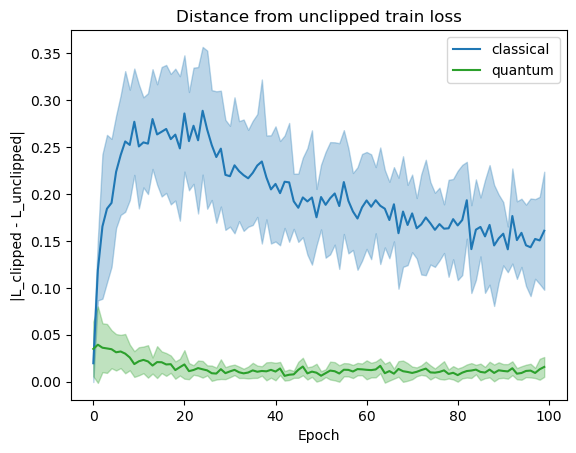

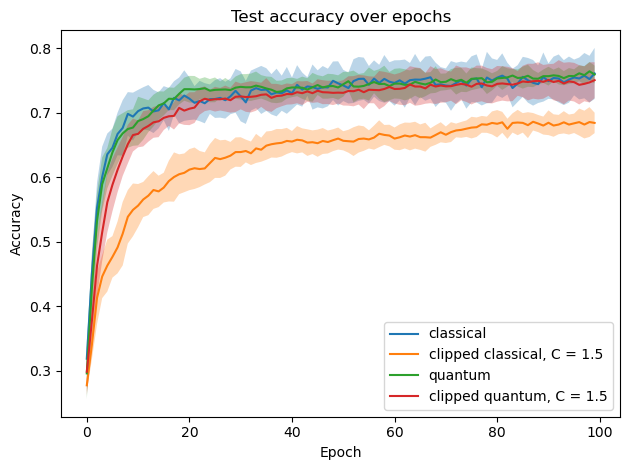

In [ ]:
for label in cfg.labels:
    if "no_privacy" not in label:
        continue
    private_label = label.split("_")[0] + "_tf_privacy"
    if private_label not in s or label not in s:
        continue
    no_priv_loss = np.array([item["train"]["loss"] for item in s[label]])
    priv_loss    = np.array([item["train"]["loss"] for item in s[private_label]])
    diff_mean, diff_std = get_mean_and_std(np.abs(no_priv_loss - priv_loss), axis=0)
    plt.plot(diff_mean, label=label_map[label].split(",")[0], color = color_map[label])
    plt.fill_between(np.arange(len(diff_mean)),
                         diff_mean - diff_std, diff_mean + diff_std, color = color_map[label], alpha=0.3)
plt.title("Distance from unclipped train loss")
plt.ylabel(r"|L_clipped - L_unclipped|")
plt.xlabel("Epoch")
plt.legend()
plt.show()


for label in cfg.labels:
    if label not in s or not s[label]:
        continue
    val_acc = np.array([item["val"]["accuracy"] for item in s[label]])
    mean, std = val_acc.mean(axis=0), val_acc.std(axis=0)
    plt.plot(mean, label=label_map[label], color = color_map[label])
    plt.fill_between(np.arange(len(mean)), mean - std, mean + std, alpha=0.3)
plt.title("Test accuracy over epochs")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()


plt.tight_layout()
plt.show()

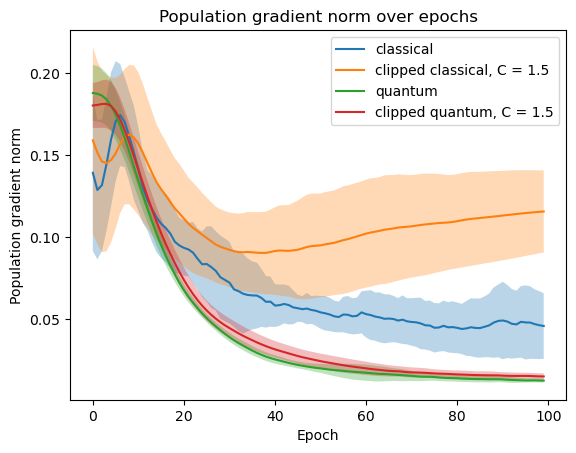

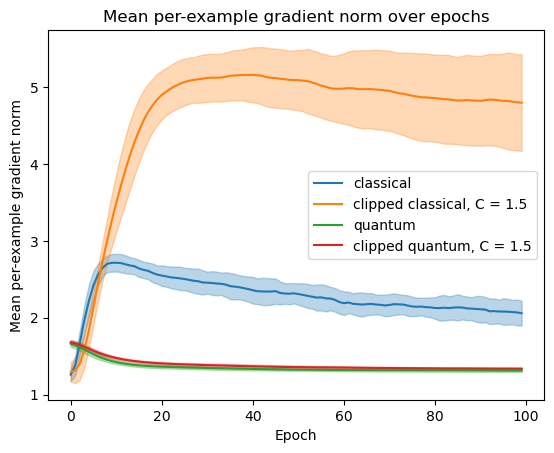

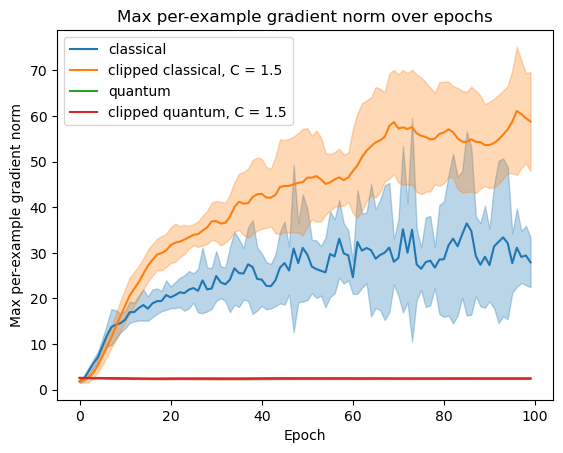

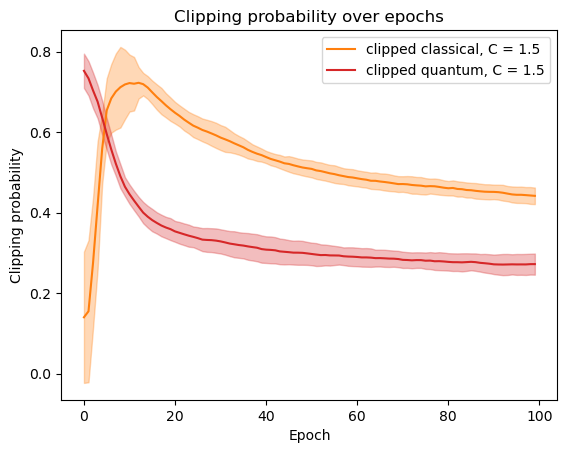

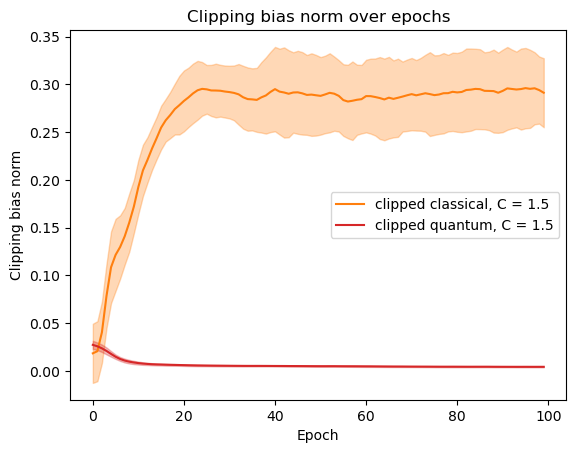

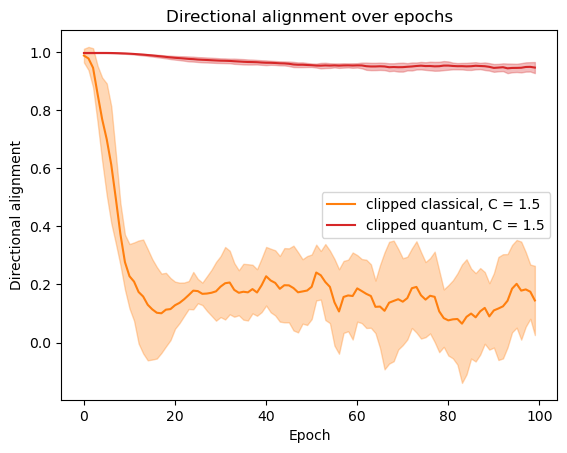

In [65]:
dfs = {}
for label in cfg.labels:
    if label not in s or not s[label]:
        continue
    df = compute_metrics_from_grad_dist(
        [item["grad_dist"] for item in s[label]],
        clip_norm=cfg.l2_clip,
        batch_size=cfg.batch_size,
        noise_multiplier=cfg.noise_multiplier,
    )
    dfs[label] = summarize_metrics_over_experiments(df)

for key, (name, requires_clip) in plottable.items():
    plt.figure()
    plotted = False
    for label in cfg.labels:
        if label not in dfs:
            continue
        if requires_clip and not is_clipped_label(label):
            continue
        if key not in dfs[label].columns.get_level_values(0):
            continue
        mean = dfs[label][key]["mean"]
        std  = dfs[label][key]["std"]
        plt.plot(mean, label=label_map[label], color = color_map[label])
        plt.fill_between(np.arange(len(mean)), mean - std, mean + std, alpha=0.3, color = color_map[label])
        plotted = True
    if not plotted:
        plt.close()
        continue
    plt.ylabel(name)
    plt.xlabel("Epoch")
    plt.title(f"{name} over epochs")
    plt.legend()
    plt.show()